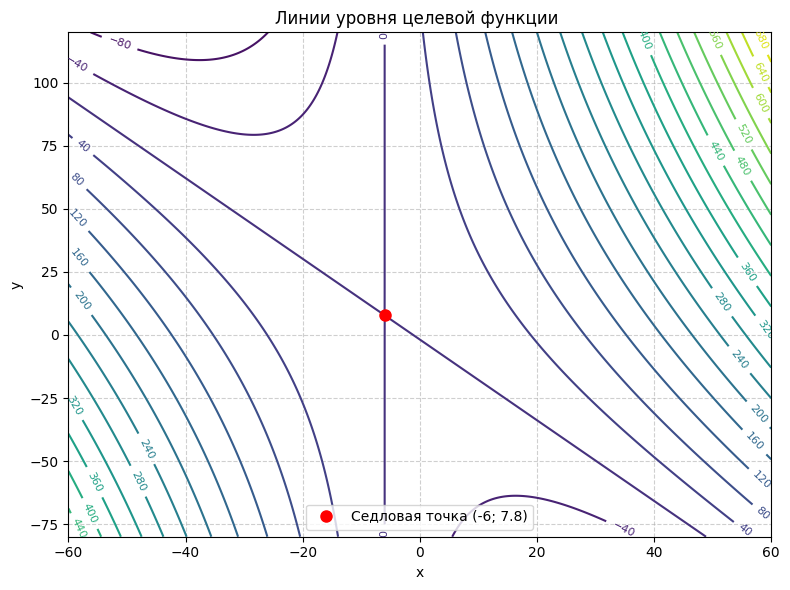

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def objective(x, y):
    return 1e-2 * (8 * x**2 + 5 * x * y + 57 * x + 30 * y + 54)

# Сетка для построения
x = np.linspace(-60.0, 60.0, 500)
y = np.linspace(-80.0, 120.0, 500)
X, Y = np.meshgrid(x, y)
Z = objective(X, Y)

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=25, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(-6.0, 7.8, 'ro', markersize=8, label='Седловая точка (-6; 7.8)')

plt.title('Линии уровня целевой функции ')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('contour_plot.png', dpi=300)
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_5879/3225031965.py:34: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(path_rmsprop_good[:, 0], path_rmsprop_good[:, 1], 'g^-', label='RMSProp ($\gamma=0.99$ - Плавный)', markersize=2)
/tmp/ipykernel_5879/3225031965.py:35: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(path_rmsprop_bad[:, 0], path_rmsprop_bad[:, 1], 'bs-', label='RMSProp ($\gamma=0.1$ - Пилообразный)', markersize=2)


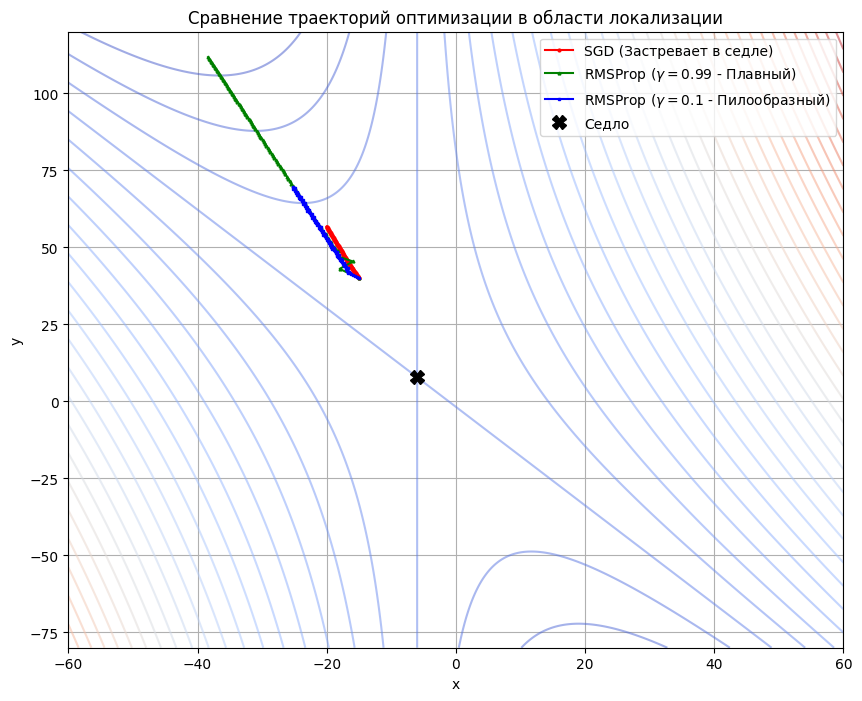

In [42]:
def gradient(x, y):
    return np.array([1e-2 * (16 * x + 5 * y + 57), 1e-2 * (5 * x + 30)])

def run_sgd(start_pt, lr=0.3, steps=98):
    history = [start_pt.copy()]
    curr = start_pt.copy()
    for _ in range(steps):
        curr -= lr * gradient(curr[0], curr[1])
        history.append(curr.copy())
    return np.array(history)

def run_rmsprop(start_pt, lr=0.3, gamma=0.99, steps=98):
    history = [start_pt.copy()]
    curr = start_pt.copy()
    G = np.zeros(2)
    eps = 1e-8
    for _ in range(steps):
        grad = gradient(curr[0], curr[1])
        G = gamma * G + (1 - gamma) * (grad ** 2)
        curr -= (lr / (np.sqrt(G) + eps)) * grad
        history.append(curr.copy())
    return np.array(history)

# Генерация данных траекторий
start = np.array([-15.0, 40.0])
path_sgd = run_sgd(start)
path_rmsprop_good = run_rmsprop(start, gamma=0.99)
path_rmsprop_bad = run_rmsprop(start, gamma=0.1)

# Отрисовка графиков траекторий
plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z, levels=35, cmap='coolwarm', alpha=0.5)
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'ro-', label='SGD (Застревает в седле)', markersize=2)
plt.plot(path_rmsprop_good[:, 0], path_rmsprop_good[:, 1], 'g^-', label='RMSProp ($\gamma=0.99$ - Плавный)', markersize=2)
plt.plot(path_rmsprop_bad[:, 0], path_rmsprop_bad[:, 1], 'bs-', label='RMSProp ($\gamma=0.1$ - Пилообразный)', markersize=2)
plt.plot(-6.0, 7.8, 'kX', markersize=10, label='Седло')

plt.title('Сравнение траекторий оптимизации в области локализации')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.savefig('paths_comparison.png', dpi=300)
plt.show()

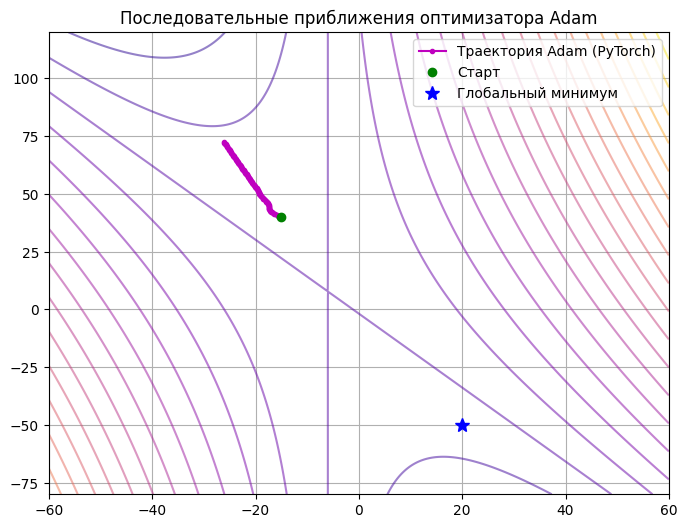

In [43]:
import torch

solution = torch.tensor([-15.0, 40.0], requires_grad=True)
optimizer = torch.optim.Adam([solution], lr=0.3)
trace = []

for i in range(98):
    optimizer.zero_grad()
    score = 1e-2 * (8 * solution[0]**2 + 5 * solution[0] * solution[1] + 57 * solution[0] + 30 * solution[1] + 54)
    score.backward()
    trace.append(solution.clone().detach().numpy())
    optimizer.step()

trace = np.array(trace)

# Отрисовка диаграммы последовательных приближений PyTorch Adam
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=25, cmap='plasma', alpha=0.5)
plt.plot(trace[:, 0], trace[:, 1], 'm.-', linewidth=1.5, label='Траектория Adam (PyTorch)')
plt.plot(-15.0, 40.0, 'go', label='Старт')
plt.plot(20.0, -50.0, 'b*', markersize=10, label='Глобальный минимум')
plt.legend()
plt.grid(True)
plt.title('Последовательные приближения оптимизатора Adam')
plt.savefig('pytorch_adam.png', dpi=300)
plt.show()